In [1]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

In [2]:
img = np.asarray(Image.open('Beckwith_Fig4.png'))

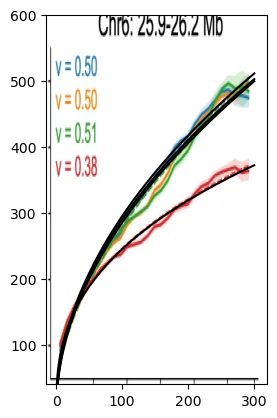

In [3]:
chrom = 6

extents = {
    'Chr17' : [-82, 802, -78, 769],
    'Chr6'  : [-498, 387, -78, 769],
}

plt.imshow(np.flip(img, axis=0)[:400, :1000],
           origin='lower',
           clip_on=True,
           extent=extents[f'Chr{chrom}'],
          )

parameters = { # parameters: [nu, d(s=100kb)]
    'RPE-1, Chr17'       : [0.33, 205],
    'HeLa, Chr17'        : [0.31, 220],
    'HeLa ΔRAD21, Chr17' : [0.45, 265],
    'HeLa ΔCTCF, Chr17'  : [0.30, 219],
    'RPE-1, Chr6'        : [0.50, 290],
    'HeLa, Chr6'         : [0.50, 295],
    'HeLa ΔRAD21, Chr6'  : [0.51, 285],
    'HeLa ΔCTCF, Chr6'   : [0.38, 245],
    'mESC (Fbn2 C65)'    : [0.4987, 0.7833*(1e5**0.4987)],
}

s = np.linspace(0, 300, 1000)
for key in parameters:
    if f'Chr{chrom}' in key:
        nu, G = parameters[key]
        G /= 100**nu

        plt.plot(s, G*s**nu, color='k')


plt.xlim([-15, 320])
plt.ylim([40, 600])
# plt.axis('equal')
plt.show()

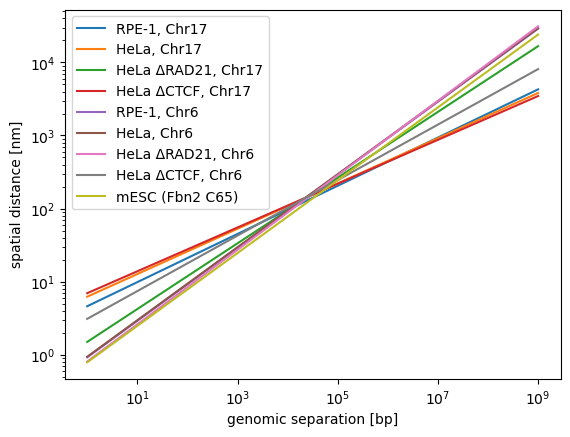

In [4]:
s = np.logspace(0, 9, 10)
for key in parameters:
    nu, G = parameters[key]
    G = G/(1e5**nu)
    plt.plot(s, G*s**nu, label=key)

plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('genomic separation [bp]')
plt.ylabel('spatial distance [nm]')
plt.show()

In [5]:
X_ref = 280 # nm
t_ref = 1100 # s

def q(alpha):
    return 1036*2.7**(-2/alpha)

def fpt(alpha, X):
    return q(alpha)*t_ref*(X**2/(6*X_ref**2))**(1/alpha)

s_bp = np.array([1e1, 1e2, 1e3, 3e3, 1e4, 3e4, 1e5, 3e5, 1e6, 1e7, 1e8, 1e9])

distance_keys = ['mESC (Fbn2 C65)', 'HeLa, Chr6', 'RPE-1, Chr6', 'HeLa, Chr17', 'RPE-1, Chr17']
value_labels = [
    ('({i})', r'distance'),
    ('', r'FPT ($\alpha=0.3$)'),
    ('', r'FPT ($\alpha=0.5$)'),
]

distance_units = {
    1   : r'\SI{}{\nano\meter}',
    1e3 : r'\SI{}{\micro\meter}',
}
time_units = {
    1e-15 : r'\SI{}{\femto\second}',
    1e-12 : r'\SI{}{\pico\second}',
    1e-9  : r'\SI{}{\nano\second}',
    1e-6  : r'\SI{}{\micro\second}',
    1e-3  : r'\SI{}{\milli\second}',
    1     : r'\SI{}{\second}',
    60    : r'\SI{}{\minute}',
    3600  : r'\SI{}{\hour}',
    3600*24 : r'\SI{}{\day}',
    3600*24*365.25 : r'\SI{}{\year}',
    3600*24*365.25*1e3 : r'\SI{}{\kilo\year}',
    3600*24*365.25*1e6 : r'\SI{}{\mega\year}',
}
def to_string(num, units):
    try:
        f = max([u for u in units.keys() if u <= num])
    except ValueError:
        f = min(units.keys())
    
    # round to two digits
    val = num/f
    scale = int(10**(np.floor(np.log10(val))))
    if scale > 1:
        val = np.round(np.round(val/scale, 1) * scale).astype(int)
        if val*f in units.keys():
            # This happens if rounding brings us to the next higher unit
            f = val*f
            val = 1
        return f"{val:d} \\\\ {units[f]}"
    elif scale == 1:
        return f"{val:.1f} \\\\ {units[f]}"
    else:
        raise RuntimeError(f"{num}")

for i, dkey in enumerate(distance_keys):
    # print(dkey)
    nu, G = parameters[dkey]
    G /= 1e5**nu
    x = G*s_bp**nu
    f03 = fpt(0.3, x)
    f05 = fpt(0.5, x)
    
    for (values, units), (ref, label) in zip(
        [(x, distance_units),
         (f03, time_units),
         (f05, time_units),
        ],
        value_labels,
    ):
        fields = [ref.format(i=i+1), label] + [f'{{${to_string(val, units)}$}}' for val in values]
        line = ' & '.join(fields) + r' \\'
        # line = re.sub(r'e\+?(-?)0*(\d+)', r'\\\\ \\times 10^{\1\2}', line)
        print(line)

    if i < len(distance_keys)-1:
        print(r'\midrule'+'\n')

(1) & distance & {$2.5 \\ \SI{}{\nano\meter}$} & {$7.8 \\ \SI{}{\nano\meter}$} & {$25 \\ \SI{}{\nano\meter}$} & {$42 \\ \SI{}{\nano\meter}$} & {$77 \\ \SI{}{\nano\meter}$} & {$130 \\ \SI{}{\nano\meter}$} & {$240 \\ \SI{}{\nano\meter}$} & {$420 \\ \SI{}{\nano\meter}$} & {$770 \\ \SI{}{\nano\meter}$} & {$2.4 \\ \SI{}{\micro\meter}$} & {$7.6 \\ \SI{}{\micro\meter}$} & {$24 \\ \SI{}{\micro\meter}$} \\
 & FPT ($\alpha=0.3$) & {$78 \\ \SI{}{\femto\second}$} & {$160 \\ \SI{}{\pico\second}$} & {$350 \\ \SI{}{\nano\second}$} & {$13 \\ \SI{}{\micro\second}$} & {$730 \\ \SI{}{\micro\second}$} & {$28 \\ \SI{}{\milli\second}$} & {$1.5 \\ \SI{}{\second}$} & {$1 \\ \SI{}{\minute}$} & {$54 \\ \SI{}{\minute}$} & {$80 \\ \SI{}{\day}$} & {$460 \\ \SI{}{\year}$} & {$970 \\ \SI{}{\kilo\year}$} \\
 & FPT ($\alpha=0.5$) & {$3.6 \\ \SI{}{\micro\second}$} & {$360 \\ \SI{}{\micro\second}$} & {$35 \\ \SI{}{\milli\second}$} & {$310 \\ \SI{}{\milli\second}$} & {$3.5 \\ \SI{}{\second}$} & {$31 \\ \SI{}{\second}$} &